# 01 · Les bases de la segmentation d'images

**Segmenter une image**, c'est donner une étiquette à chaque pixel : « animal », « fond », « route »…

Dans ce notebook, on découvre 3 méthodes, de la plus simple à la plus puissante :
1. **Le seuillage** : séparer les pixels clairs des pixels sombres
2. **Les contours** (Canny) : trouver les frontières entre les objets
3. **K-means** : regrouper les pixels par couleur

Et pour finir, un aperçu de ce que fait un **réseau de neurones** (YOLO).

**Prérequis :** Python et NumPy de base.

## 0. Préparation

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def afficher(images, titres):
    # Affiche plusieurs images côte à côte
    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    for ax, img, titre in zip(axes, images, titres):
        ax.imshow(img, cmap="gray")
        ax.set_title(titre)
        ax.axis("off")
    plt.show()

## 1. Charger une image

OpenCV lit les images en **BGR** (Bleu, Vert, Rouge), alors que matplotlib attend du **RGB**. On convertit donc.

Couleur : (375, 500, 3)   Gris : (375, 500)


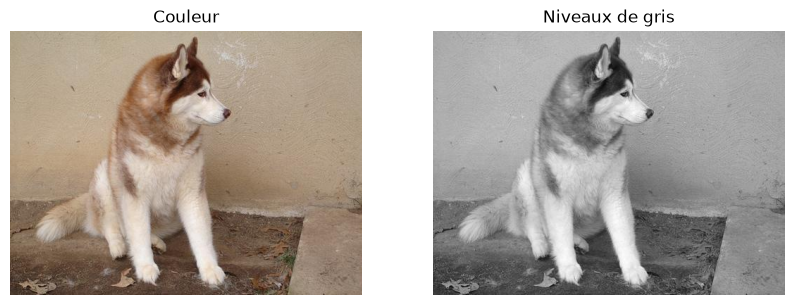

In [2]:
img_bgr = cv2.imread("../../img/dog.png")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

print("Couleur :", img_rgb.shape, "  Gris :", gris.shape)
afficher([img_rgb, gris], ["Couleur", "Niveaux de gris"])

## 2. Le seuillage

L'idée la plus simple : on choisit un **seuil** (ici 127).
- pixel > 127 → blanc (255)
- pixel ≤ 127 → noir (0)

On obtient une image **binaire** : 2 classes seulement.

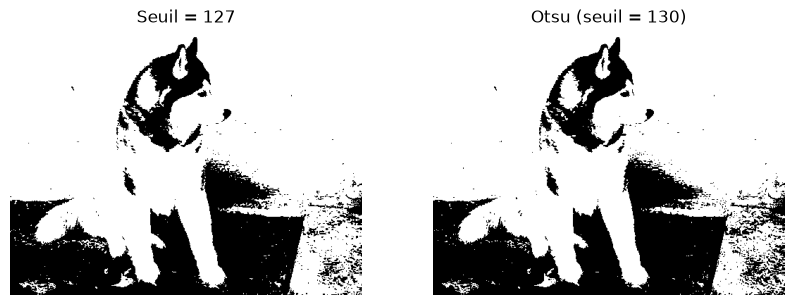

In [3]:
_, binaire = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)

# Otsu choisit le seuil automatiquement à partir de l'histogramme
seuil_otsu, binaire_otsu = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

afficher([binaire, binaire_otsu], ["Seuil = 127", f"Otsu (seuil = {seuil_otsu:.0f})"])

**Limite :** le seuillage ne regarde que la luminosité. Un animal sombre sur un fond sombre ne sera pas séparé.

## 3. Les contours (Canny)

Au lieu de classer les pixels, on cherche les **frontières** : les endroits où la luminosité change brusquement.

On applique d'abord un **flou** pour enlever le bruit, sinon chaque petit détail devient un contour.

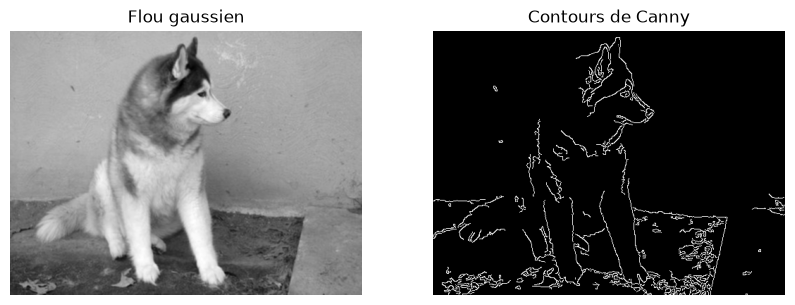

In [4]:
flou = cv2.GaussianBlur(gris, (3, 3), 0)
contours = cv2.Canny(flou, 50, 150)   # 50 et 150 : seuils bas et haut

afficher([flou, contours], ["Flou gaussien", "Contours de Canny"])

**Limite :** on obtient des lignes, pas des régions. Le contour n'est pas toujours fermé.

## 4. K-means : regrouper les pixels par couleur

Chaque pixel est un point `(B, V, R)` dans l'espace des couleurs.
K-means les range en **K groupes** de couleurs proches, puis remplace chaque pixel par la couleur moyenne de son groupe.

In [5]:
image = cv2.imread("../../img/dog_cat.png")

# Une ligne par pixel, 3 colonnes (B, V, R)
pixels = np.float32(image.reshape(-1, 3))

K = 5
criteres = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centres = cv2.kmeans(pixels, K, None, criteres, 10, cv2.KMEANS_PP_CENTERS)

print("labels :", labels.shape, "-> le numéro de groupe de chaque pixel")
print("centres :", centres.shape, "-> la couleur moyenne de chaque groupe")

labels : (39960, 1) -> le numéro de groupe de chaque pixel
centres : (5, 3) -> la couleur moyenne de chaque groupe


### L'astuce pour reconstruire l'image

`centres[labels]` remplace chaque numéro de groupe par la couleur correspondante. Petit exemple :

In [6]:
couleurs = np.array([10, 20, 30])
groupes = np.array([0, 0, 2, 1])
couleurs[groupes]   # -> [10, 10, 30, 20]

array([10, 10, 30, 20])

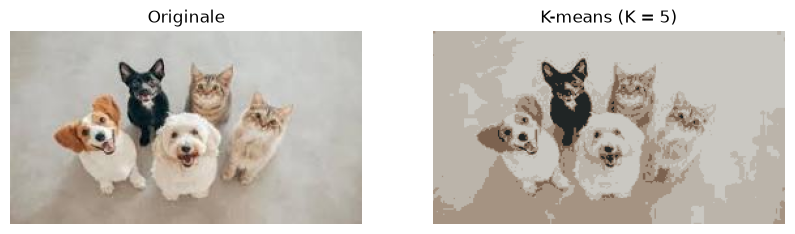

In [7]:
segmentee = np.uint8(centres)[labels.flatten()].reshape(image.shape)

afficher([cv2.cvtColor(image, cv2.COLOR_BGR2RGB), cv2.cvtColor(segmentee, cv2.COLOR_BGR2RGB)],
         ["Originale", f"K-means (K = {K})"])

**Limite :** K-means ne sait pas ce qu'est un « chien ». Il groupe seulement des couleurs proches.

## 5. Aperçu : un réseau de neurones (YOLO)

Un réseau entraîné sur des milliers d'images **reconnaît les objets** et donne un masque par objet.
Comment ça marche à l'intérieur ? C'est le sujet des notebooks suivants.

Objets trouvés : ['dog', 'cat', 'dog', 'dog', 'cat']


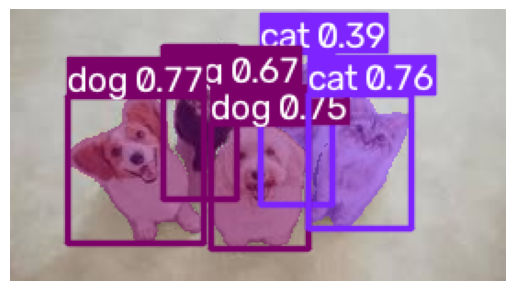

In [8]:
from ultralytics import YOLO

modele = YOLO("../../models/yolo26n-seg.pt")
resultat = modele.predict("../../img/dog_cat.png", verbose=False)[0]

print("Objets trouvés :", [resultat.names[int(c)] for c in resultat.boxes.cls])
plt.imshow(resultat.plot()[:, :, ::-1])   # plot() renvoie du BGR
plt.axis("off")
plt.show()

## Récapitulatif

| Méthode | Regarde | Limite |
|---|---|---|
| Seuillage | la luminosité | 2 classes seulement |
| Canny | les changements brusques | des lignes, pas des régions |
| K-means | la couleur | ne comprend pas les objets |
| YOLO | des motifs appris | il faut l'entraîner |



**Suite :** [02 · Feature maps](02_feature_maps.ipynb)